# Dataset Creation

In this section we build the **guitar macro-genre dataset** starting from raw audio loops.
We will:

- Load all audio files from the source folders.
- Map each loop pack into a **macro-genre** (e.g., `funk_disco`, `house`, `hip_hop_trap`).
- Convert each file (and its augmentations) into a **log-mel spectrogram**.
- Cache the result as `.npy` files plus an `index.json` with all metadata.

This cell sets up the preprocessing environment and global configuration for the guitar-genre dataset.  
It imports all needed libraries, defines paths for raw audio and cached mel-spectrograms, configures audio/Mel parameters, and maps original loop folders into a smaller set of macro-genres.  
Finally, it builds the macro-class index and selects the compute device (CUDA / MPS / CPU).

### Imports
- **os** — generic filesystem utilities (renaming, path checks, etc. if needed later).
- **json** — read/write the `index.json` metadata for cached mel-spectrograms.
- **random** — random choices for augmentation or sampling.
- **torch** — core tensor library and device management (CPU/GPU/MPS).
- **torchaudio** — audio I/O and transforms (STFT, MelSpectrogram, filters).
- **numpy** — numerical arrays and `.npy` file handling.
- **matplotlib.pyplot** — plotting and inspecting spectrograms.
- **torch.nn.functional as F** — functional ops (padding, pooling, etc.).
- **pathlib.Path** — clean, OS-independent path handling.
- **tqdm.tqdm** — progress bars for long preprocessing loops.

### Constants and settings
- **INPUT_ROOT** — root folder containing the original audio loops grouped by pack.
- **CACHE_ROOT** — output folder where mel-spectrogram `.npy` files will be saved.
- **INDEX_PATH** — JSON file path for the cached index (`CACHE_ROOT/index.json`).

- **BACKEND** — feature backend type (`"mel"` for mel-spectrograms).
- **COLORMAP** — default colormap name (`"magma"`) for spectrogram visualization.
- **SR** — target sample rate (44.1 kHz).
- **N_FFT** — FFT window size (4096 samples).
- **HOP** — hop length between STFT frames (256 samples).
- **N_MELS** — number of mel frequency bins (256).
- **FMIN / FMAX** — min/max frequency in Hz for the mel filterbank.
- **DB_LO / DB_H** — lower and upper bounds of the dB range used for normalization.
- **WINDOW** — type of analysis window (`"hann"`).
- **CHUNK_S** — chunk length in seconds used when splitting long audio during preprocessing.
- **W / H** — target display size (width/height) for plotting or UI rendering.

- **MACRO_MAP** — mapping from original loop-pack folder names to macro-genre labels.
- **CLASSES** — list of all original folder paths found under `INPUT_ROOT`.
- **MACRO_CLASSES** — sorted list of unique macro-genre names.
- **MACRO_TO_IDX** — dictionary mapping each macro-genre name to an integer class index.

- **INDEX** — dictionary that will collect metadata about cached mel files (class names, items, and spectrogram parameters).
- **DEVICE** — selected compute device: CUDA → MPS → CPU (in that priority).

In [10]:
import os
import json
import random
import torch
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from pathlib import Path
from tqdm import tqdm

INPUT_ROOT = Path("../../data/dataset/audio")
CACHE_ROOT = Path("../../data/dataset/guitar_mel")
INDEX_PATH = CACHE_ROOT / "index.json"

CACHE_ROOT.mkdir(parents=True, exist_ok=True)

BACKEND  = "mel"
COLORMAP = "magma"
SR       = 44100
N_FFT    = 4096
HOP      = 256
N_MELS   = 256
FMIN     = 20
FMAX     = SR // 2
DB_LO    = -80.0
DB_H     = 0.0
WINDOW   = "hann"
CHUNK_S  = 10.0
W        = 512
H        = 256

MACRO_MAP = {
    "09 Disco Funk": "funk_disco",
    "08 Indie Disco": "funk_disco",
    "Cory Wong": "funk_disco",
    "21 Prismatica": "funk_disco",
    "Watch the Sound": "funk_disco",

    "06 Deep House": "house",
    "05 Tech House": "house",

    "01 Hip Hop": "hip_hop_trap",
    "Beat Tape": "hip_hop_trap",
    "Soulection": "hip_hop_trap",
    "24 Vision and Verse": "hip_hop_trap",
    "22 Skyline Heat": "hip_hop_trap",
    "Backlight Bounce": "hip_hop_trap",
    "Take A Daytrip": "hip_hop_trap",

    "11 Blues Garage": "rock_blues",
    "Jam Pack Rhythm Section": "rock_blues",
    "Apple Loops for GarageBand": "rock_blues",

    "Tom Misch": "neo_soul_rnb",
    "The Kount": "neo_soul_rnb",
    "TRAKGIRL": "neo_soul_rnb",
    "07 Chillwave": "neo_soul_rnb",

    "Jam Pack World Music": "world",
    "15 Reggaeton Pop": "world",

    "Oak Felder": "pop_cinematic",
    "Session Player": "pop_cinematic",
    "PomPom": "pop_cinematic",

    "Jam Pack 1": "misc_fx",
    "Jam Pack Remix Tools": "misc_fx",
    "18 Toy Box": "misc_fx",
    "25 Step Sequencer": "misc_fx",
}

CLASSES = [d for d in sorted(INPUT_ROOT.iterdir()) if d.is_dir()]

MACRO_CLASSES = sorted(set(MACRO_MAP.values()) | {"misc_fx"})
MACRO_TO_IDX = {name: i for i, name in enumerate(MACRO_CLASSES)}

INDEX = {"classes": MACRO_CLASSES, "items": [], "params": {"sr": SR, "n_fft": N_FFT, "hop": HOP, "n_mels": N_MELS, "fmin": FMIN, "fmax": FMAX, "backend": "mel_db",}}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available() else "cpu")

print(f"Using {DEVICE}")
print("Macro-classes:", MACRO_CLASSES)

Using mps
Macro-classes: ['funk_disco', 'hip_hop_trap', 'house', 'misc_fx', 'neo_soul_rnb', 'pop_cinematic', 'rock_blues', 'world']


## Mel-spectrogram transforms, augmentation and caching

This cell defines the full **audio → mel-spectrogram → cache** pipeline:

- Builds GPU-ready `MelSpectrogram` and `AmplitudeToDB` transforms (`mel_tf`, `db_tf`).
- Implements `load_mono_resampled(...)` to:
  - load audio, mix to mono, resample to `SR`
  - normalize amplitude to `[-1, 1]`.
- Defines `augment_waveform(...)` to create multiple augmented versions of each clip by:
  - random gain
  - low-level Gaussian noise
  - random high-pass / low-pass filtering.
- Implements `mel_db_chunks(...)`:
  - pads short clips
  - splits long clips into `CHUNK_S`-second chunks
  - converts each chunk to **log-mel dB** and concatenates along time.

Finally, it:

- Iterates over all source folders, maps them to a **macro-class**, and collects all `.wav` files.
- For each file:
  - generates the original + augmented waveforms,
  - converts each to a mel-spectrogram and saves it as `.npy` in `CACHE_ROOT/<macro_class>/`,
  - registers an entry in `INDEX["items"]` with path, shape and class index.
- Writes the final `index.json` and prints how many items were cached.

In [11]:
mel_tf = torchaudio.transforms.MelSpectrogram(
    sample_rate=SR,
    n_fft=N_FFT,
    hop_length=HOP,
    win_length=N_FFT,
    f_min=float(FMIN),
    f_max=float(FMAX),
    n_mels=N_MELS,
    window_fn=torch.hann_window,
    power=2.0,
    center=False,
    norm=None,
    mel_scale="htk",
).to(DEVICE)

db_tf = torchaudio.transforms.AmplitudeToDB(
    stype="power",
    top_db=abs(DB_LO),
).to(DEVICE)


def load_mono_resampled(path: Path) -> torch.Tensor:
    wav, sr = torchaudio.load(str(path))
    if wav.size(0) > 1:
        wav = wav.mean(dim=0, keepdim=True)
    if sr != SR:
        wav = torchaudio.functional.resample(wav, sr, SR)
    wav = wav / max(1e-8, wav.abs().max())
    return wav.contiguous()


def augment_waveform(wav: torch.Tensor, n_aug: int = 5) -> list[torch.Tensor]:
    outs = []
    for _ in range(n_aug):
        x = wav.clone()
        gain_db = random.uniform(-3.0, 3.0)
        gain = 10.0 ** (gain_db / 20.0)
        x = x * gain
        noise_level = random.uniform(0.001, 0.01)
        noise = torch.randn_like(x) * noise_level
        x = x + noise
        if random.random() < 0.5:
            cutoff = random.uniform(200.0, 3000.0)
            x = torchaudio.functional.highpass_biquad(x, SR, cutoff)
        else:
            cutoff = random.uniform(3000.0, 9000.0)
            x = torchaudio.functional.lowpass_biquad(x, SR, cutoff)
        x = torch.clamp(x, -1.0, 1.0)
        outs.append(x.contiguous())
    return outs


@torch.inference_mode()
def mel_db_chunks(wav_cpu: torch.Tensor) -> np.ndarray:
    T = wav_cpu.shape[-1]
    if T < N_FFT:
        wav_cpu = F.pad(wav_cpu, (0, N_FFT - T))
        T = wav_cpu.shape[-1]

    chunk_len = int(CHUNK_S * SR)
    chunks = [wav_cpu[:, s:min(s + chunk_len, T)] for s in range(0, T, chunk_len)] if chunk_len > 0 else [wav_cpu]
    out = []

    for ch in chunks:
        x = ch.to(DEVICE)
        if x.shape[-1] < N_FFT:
            x = F.pad(x, (0, N_FFT - x.shape[-1]))
        S = mel_tf(x)
        S_db = db_tf(S).squeeze(0)
        out.append(S_db.cpu())

    X = torch.cat(out, dim=1).numpy().astype(np.float32)
    X = np.nan_to_num(X, nan=DB_LO, neginf=DB_LO, posinf=DB_H)
    return X


all_files = []
for cdir in CLASSES:
    macro_name = MACRO_MAP.get(cdir.name, "misc_fx")
    macro_idx = MACRO_TO_IDX[macro_name]
    for f in sorted(cdir.glob("*.wav")):
        all_files.append((macro_idx, macro_name, f))

total = len(all_files)

pbar = tqdm(all_files, desc="Mel caching", total=total)
for ci, cname, f in pbar:
    try:
        wav = load_mono_resampled(f)
        aug_wavs = [wav] + augment_waveform(wav, n_aug=5)

        out_dir = CACHE_ROOT / cname
        out_dir.mkdir(parents=True, exist_ok=True)

        for aug_idx, w in enumerate(aug_wavs):
            if aug_idx == 0:
                stem = f.stem
            else:
                stem = f"{f.stem}_aug{aug_idx}"

            X = mel_db_chunks(w)
            X16 = X.astype(np.float16)

            out_npy = out_dir / (stem + ".npy")
            np.save(out_npy, X16)

            INDEX["items"].append(
                {
                    "mel_path": str(out_npy),
                    "class_idx": ci,
                    "n_mels": int(X16.shape[0]),
                    "n_frames": int(X16.shape[1]),
                    "stem": stem,
                }
            )

        pbar.set_postfix_str(f"{cname}/{f.name}", refresh=False)
    except Exception as e:
        pbar.set_postfix_str(f"[WARN] {f.name}: {e}", refresh=False)

pbar.close()

with open(CACHE_ROOT / "index.json", "w") as fp:
    json.dump(INDEX, fp)

print(f"Done. Cached mel in: {CACHE_ROOT} — items: {len(INDEX['items'])}")

Mel caching: 100%|██████████| 1337/1337 [02:26<00:00,  9.13it/s, funk_disco/Warm Embers Guitar 09.wav]                  


Done. Cached mel in: ../../data/dataset/guitar_mel — items: 8022


## Deterministic renaming of cached mel files

This cell enforces a clean, **deterministic naming scheme** for all cached `.npy` files:

- Loads `index.json` and extracts `items` and `classes`.
- Builds a per-class counter, then for each item:
  - computes a new name `"<class>_<000001>.npy"` (zero-padded index per macro-class),
  - stores the mapping from old path → new path.
- Renames all files on disk using `os.rename`.
- Updates every `it["mel_path"]` and `it["stem"]` in `items` to reflect the new names.
- Writes the updated `index.json` and prints a confirmation message.

Result: each macro-class folder contains consistently named files like  
`funk_disco_000001.npy`, `funk_disco_000002.npy`, … which makes debugging and
dataset inspection much easier.

In [12]:
with open(INDEX_PATH, "r") as f:
    idx = json.load(f)

items = idx["items"]
classes = idx["classes"]

counter = {c: 1 for c in classes}
rename_map = {}

for it in items:
    old_path = Path(it["mel_path"])
    cname = classes[it["class_idx"]]

    new_name = f"{cname}_{counter[cname]:06d}.npy"
    new_path = old_path.parent / new_name

    rename_map[str(old_path)] = str(new_path)
    counter[cname] += 1

for old, new in rename_map.items():
    os.rename(old, new)

for it in items:
    it["mel_path"] = rename_map[it["mel_path"]]
    stem = Path(it["mel_path"]).stem
    it["stem"] = stem

with open(INDEX_PATH, "w") as f:
    json.dump(idx, f)

print("Done renaming.")

Done renaming.


## Quick visual check of cached mel-spectrograms

This cell performs a **sanity check** on the cached dataset:

- Loads `index.json` from `CACHE_ROOT` and reads `classes` and `items`.
- Randomly samples **two** entries from the cached mel list.
- For each sample:
  - loads the corresponding `.npy` mel-spectrogram,
  - displays it with `matplotlib.imshow` using the chosen `COLORMAP`,
  - adds a title with `"<macro_class> — <stem>"` plus axis labels.

Result: you get a side-by-side visualization of two random mel-spectrograms,
to quickly verify that preprocessing, normalization and caching are working as expected.

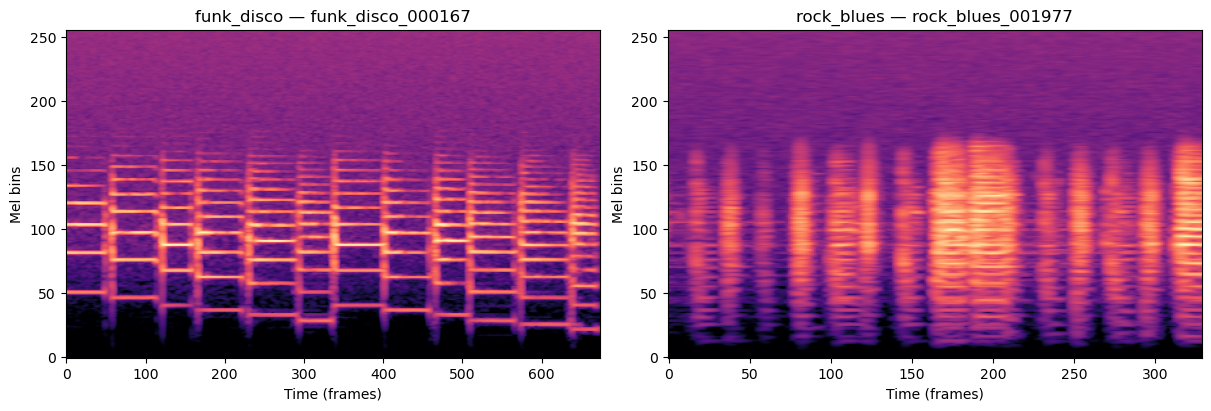

In [13]:
with open(CACHE_ROOT / "index.json") as f:
    idx = json.load(f)

classes = idx["classes"]
items = idx["items"]

samples = random.sample(items, 2)

fig, axs = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, it in zip(axs, samples):
    X = np.load(it["mel_path"]).astype(np.float32)
    ax.imshow(X, origin="lower", aspect="auto", cmap=COLORMAP)
    ax.set_title(f"{classes[it['class_idx']]} — {it['stem']}")
    ax.set_xlabel("Time (frames)")
    ax.set_ylabel("Mel bins")

plt.show()

The two images show real mel-spectrograms extracted from the dataset after
preprocessing and normalization.  
On the left is an example from the **funk_disco** macro-class, featuring
regular rhythmic patterns and strong percussive structure.  
On the right is a **rock_blues** sample, characterized by denser spectra and
broader harmonic variations.  
This visualization confirms that the caching pipeline works correctly and that
each macro-genre exhibits distinctive spectral textures.